In [1]:
import os
print(os.getcwd())
os.environ["NUPLAN_MAPS_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset/maps")
# os.environ["NAVSIM_EXP_ROOT"] = os.path.expandvars("$HOME/Code/navsim/exp")
# os.environ["NAVSIM_DEVKIT_ROOT"] = os.path.expandvars("$HOME/Code/navsim/GTRS")
os.environ["OPENSCENE_DATA_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset")
# os.environ["NAVSIM_TRAJPDM_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset/traj_pdm_v2")

from pathlib import Path

import hydra
from hydra.utils import instantiate
import matplotlib.pyplot as plt

from navsim.common.dataloader import SceneLoader
from navsim.common.dataclasses import SceneFilter, SensorConfig
from hydra.core.global_hydra import GlobalHydra
SPLIT = "mini"  # ["mini", "test", "trainval"]
FILTER = "all_scenes"
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()
hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")
cfg = hydra.compose(config_name=FILTER)
print(cfg)
scene_filter: SceneFilter = instantiate(cfg)
# scene_filter.max_scenes = 8
openscene_data_root = Path(os.getenv("OPENSCENE_DATA_ROOT"))

scene_loader = SceneLoader(
    openscene_data_root / f"navsim_logs/{SPLIT}", # data_path
    openscene_data_root / f"sensor_blobs/{SPLIT}", # original_sensor_path
    scene_filter,
    openscene_data_root / "warmup_two_stage/sensor_blobs", # synthetic_sensor_path
    openscene_data_root / "warmup_two_stage/synthetic_scene_pickles", # synthetic_scenes_path
    sensor_config=SensorConfig.build_all_sensors(),
)

/Users/chenran/Code/e2e_av_from_scratch/phase-2 model


/var/folders/1k/q487h1g17y79bb1bj_jrhl5w0000gn/T/ipykernel_96249/3757473776.py:22: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")


{'_target_': 'navsim.common.dataclasses.SceneFilter', '_convert_': 'all', 'num_history_frames': 4, 'num_future_frames': 10, 'frame_interval': None, 'has_route': True, 'max_scenes': None, 'log_names': None, 'tokens': None}


Loading logs: 100%|██████████| 64/64 [00:01<00:00, 38.48it/s]


In [2]:
from transfuer import TransfuserModel, TRANSFUSER_CONFIG
import torch
ckpt = torch.load('../model_weights/transfuser_seed_0.ckpt', map_location='cpu')
state_dict = ckpt['state_dict']
state_dict = {
    k.replace("agent._transfuser_model.", ""): v
    for k, v in state_dict.items()
    if k.startswith("agent._transfuser_model.")
}

model = TransfuserModel(TRANSFUSER_CONFIG)
model.load_state_dict(state_dict, strict=True)

/Users/chenran/Code/e2e_av_from_scratch/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

In [6]:
from dataset import Dataset
from torch.utils.data.dataloader import DataLoader

dataset = Dataset(scene_loader=scene_loader, max_len=8)
data_loader = DataLoader(dataset=dataset, batch_size=1, shuffle=True)

for features, targets in data_loader:
    print(features.keys())
    print(features['camera_feature'].shape, features['lidar_feature'].shape, features['status_feature'])
    print(targets.keys())
    output = model(features)
    break


dict_keys(['camera_feature', 'lidar_feature', 'status_feature'])
torch.Size([1, 3, 256, 1024]) torch.Size([1, 1, 256, 256]) tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00, -3.6157e-03,
         -3.2762e-04, -2.4276e-02, -1.6192e-03]])
dict_keys(['trajectory', 'agent_states', 'agent_labels', 'bev_semantic_map'])


In [4]:
output

{'bev_semantic_map': tensor([[[[ 7.8875e+00,  7.8875e+00,  8.6300e+00,  ...,  1.8091e+00,
             1.7405e+00,  1.7405e+00],
           [ 8.8325e+00,  8.8325e+00,  9.6342e+00,  ...,  2.0427e+00,
             1.9543e+00,  1.9543e+00],
           [ 1.0723e+01,  1.0723e+01,  1.1642e+01,  ...,  2.5100e+00,
             2.3817e+00,  2.3817e+00],
           ...,
           [ 6.1308e+00,  6.1308e+00,  6.3798e+00,  ...,  6.1263e+00,
             6.0552e+00,  6.0552e+00],
           [ 5.2069e+00,  5.2069e+00,  5.3900e+00,  ...,  5.0557e+00,
             4.9888e+00,  4.9888e+00],
           [ 4.7450e+00,  4.7450e+00,  4.8951e+00,  ...,  4.5204e+00,
             4.4556e+00,  4.4556e+00]],
 
          [[-4.2006e+00, -4.2006e+00, -4.3171e+00,  ..., -2.5593e-01,
            -2.7757e-01, -2.7757e-01],
           [-4.1361e+00, -4.1361e+00, -4.2801e+00,  ..., -1.9284e-01,
            -2.2315e-01, -2.2315e-01],
           [-4.0072e+00, -4.0072e+00, -4.2062e+00,  ..., -6.6662e-02,
            -1.1430

In [9]:
for k, v in output.items():
    print(f'{k}: shape {v.shape}')

bev_semantic_map: shape torch.Size([1, 7, 128, 256])
trajectory: shape torch.Size([1, 8, 3])
agent_states: shape torch.Size([1, 30, 5])
agent_labels: shape torch.Size([1, 30])


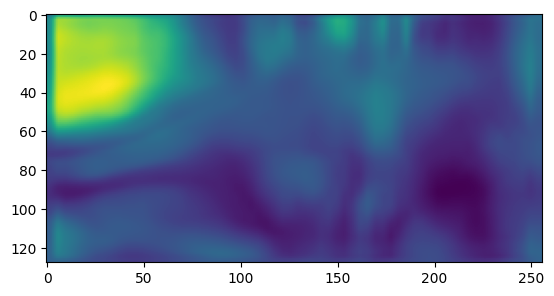

In [19]:
plt.imshow(output['bev_semantic_map'][0][6].detach().numpy())

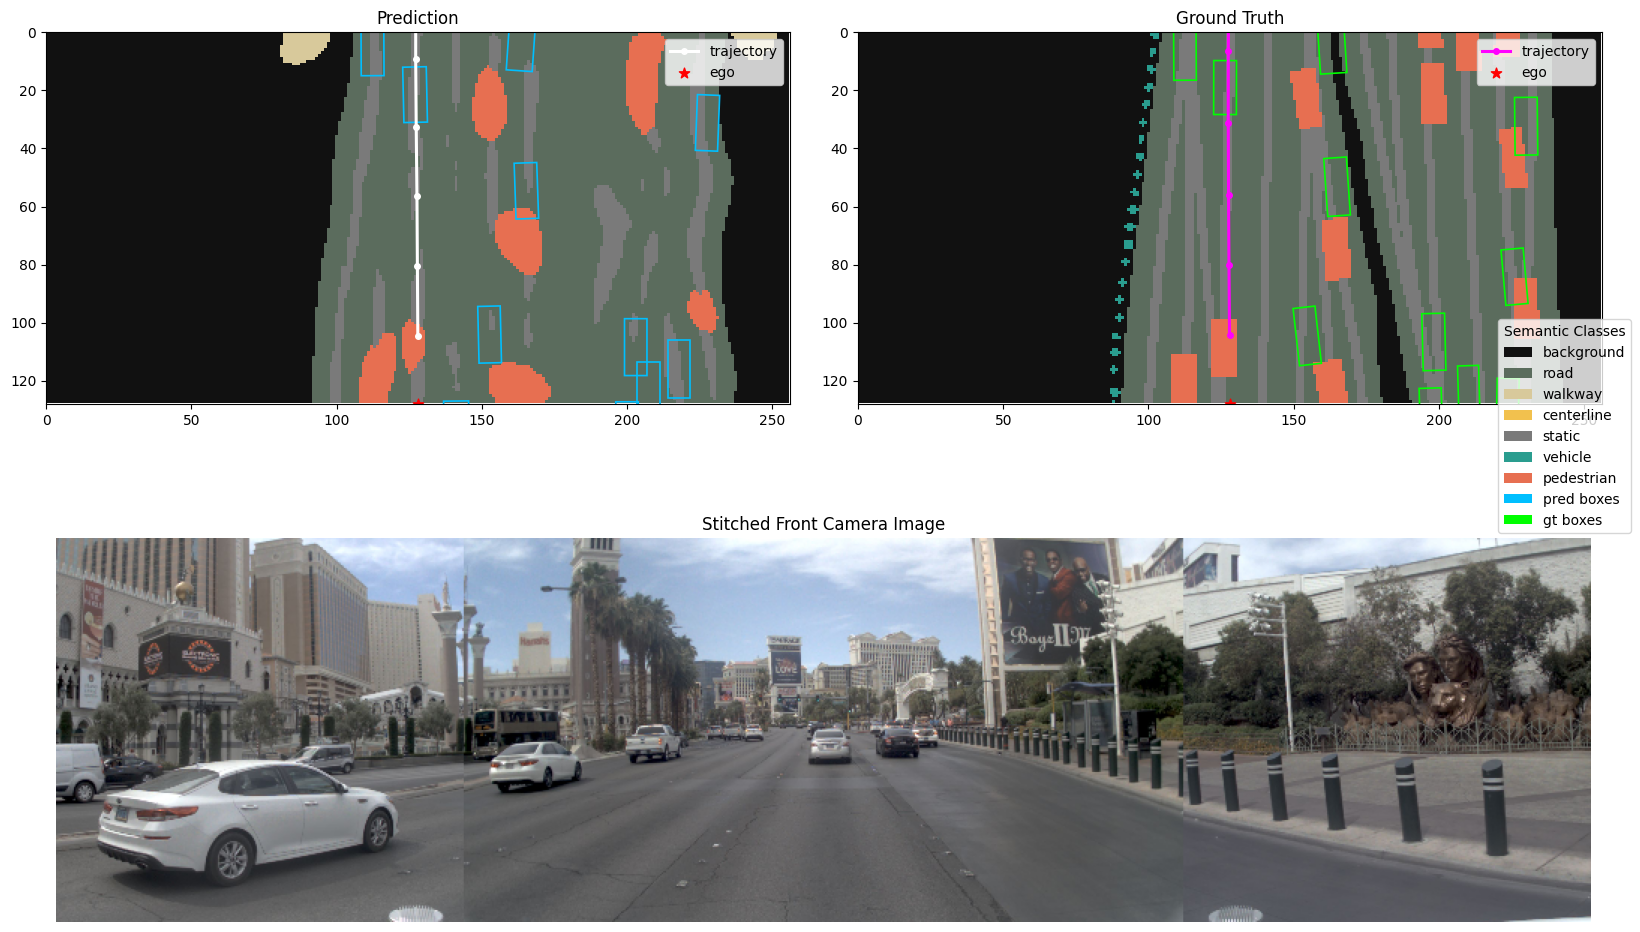

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle

pred_bev = output['bev_semantic_map'][0].detach().cpu().numpy().argmax(axis=0)
pred_traj = output['trajectory'][0].detach().cpu().numpy()
pred_boxes = output['agent_states'][0].detach().cpu().numpy()
pred_scores = output['agent_labels'][0].detach().cpu().numpy()

gt_bev = targets['bev_semantic_map'][0].detach().cpu().numpy()
gt_traj = targets['trajectory'][0].detach().cpu().numpy()
gt_boxes = targets['agent_states'][0].detach().cpu().numpy()
gt_scores = targets['agent_labels'][0].detach().cpu().numpy()
camera_image = features['camera_feature'][0].detach().cpu().permute(1, 2, 0).numpy()

PIXELS_PER_METER = 4.0
Y_MIN = -32.0
X_MAX = 32.0
BEV_WIDTH = pred_bev.shape[1]
BEV_HEIGHT = pred_bev.shape[0]

def ego_to_pixel(x, y):
    px = (y - Y_MIN) * PIXELS_PER_METER
    py = (X_MAX - x) * PIXELS_PER_METER
    return px, py

def plot_box(ax, box, color, linewidth=1.5):
    x, y, heading, length, width = box
    cx, cy = ego_to_pixel(x, y)
    rect = Rectangle(
        (cx - width * PIXELS_PER_METER / 2.0, cy - length * PIXELS_PER_METER / 2.0),
        width * PIXELS_PER_METER,
        length * PIXELS_PER_METER,
        angle=-np.degrees(heading),
        rotation_point='center',
        fill=False,
        edgecolor=color,
        linewidth=linewidth,
    )
    ax.add_patch(rect)

def plot_traj(ax, traj, color, label, linestyle='-', marker='o'):
    traj_px = np.array([ego_to_pixel(x, y) for x, y, _ in traj])
    ax.plot(traj_px[:, 0], traj_px[:, 1], color=color, linewidth=2.2, linestyle=linestyle, marker=marker, markersize=4, label=label)

def draw_panel(ax, bev_map, boxes, scores, traj, title, box_color, traj_color):
    ax.imshow(bev_map, cmap=ListedColormap(class_colors), interpolation='nearest')
    valid_mask = scores > 0
    for box in boxes[valid_mask]:
        plot_box(ax, box, color=box_color, linewidth=1.2)
    plot_traj(ax, traj, color=traj_color, label='trajectory')
    ego_px = ego_to_pixel(0.0, 0.0)
    ax.scatter(*ego_px, color='red', s=60, marker='*', label='ego')
    ax.set_title(title)
    ax.set_xlim(0, BEV_WIDTH)
    ax.set_ylim(BEV_HEIGHT, 0)
    ax.set_aspect('equal')
    ax.legend(loc='upper right')

class_names = ['background', 'road', 'walkway', 'centerline', 'static', 'vehicle', 'pedestrian']
class_colors = ['#111111', '#5b6c5d', '#d8c99b', '#f2c14e', '#7a7a7a', '#2a9d8f', '#e76f51']
class_handles = [Patch(facecolor=color, edgecolor='none', label=name) for name, color in zip(class_names, class_colors)]
overlay_handles = [
    Patch(facecolor='deepskyblue', edgecolor='none', label='pred boxes'),
    Patch(facecolor='lime', edgecolor='none', label='gt boxes'),
]

fig = plt.figure(figsize=(16, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[3, 2])
ax_pred = fig.add_subplot(gs[0, 0])
ax_gt = fig.add_subplot(gs[0, 1])
ax_cam = fig.add_subplot(gs[1, :])

draw_panel(ax_pred, pred_bev, pred_boxes, pred_scores, pred_traj, 'Prediction', 'deepskyblue', 'white')
draw_panel(ax_gt, gt_bev, gt_boxes, gt_scores, gt_traj, 'Ground Truth', 'lime', 'magenta')

ax_cam.imshow(camera_image)
ax_cam.set_title('Stitched Front Camera Image')
ax_cam.axis('off')

fig.legend(handles=class_handles + overlay_handles, loc='center right', bbox_to_anchor=(1.02, 0.5), frameon=True, title='Semantic Classes')
plt.show()
